# Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, precision_recall_curve, auc
)

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)


# Load saved scores/predictions

In [3]:
iso = pd.read_csv("iso_scores.csv")
ae = pd.read_csv("ae_scores.csv")




In [4]:
df_scores = pd.DataFrame({
    "y_true": iso["y_true"],
    "iso_anomaly_score": iso["iso_anomaly_score"],
    "ae_recon_error": ae["ae_recon_error"]
})


In [5]:
df_scores.head()

,y_true,iso_anomaly_score,ae_recon_error
0,0,-0.141057,4.218163
1,0,-0.263860,0.305258
2,0,-0.178793,0.933014
3,0,-0.262598,0.370216
4,0,-0.245019,0.809598


# Compute Metrics for Both Models (ROC-AUC & PR-AUC)

In [6]:
y_true = df_scores["y_true"].values

# Isolation Forest
iso_scores = df_scores["iso_anomaly_score"].values
iso_roc = roc_auc_score(y_true, iso_scores)
iso_prec, iso_rec, _ = precision_recall_curve(y_true, iso_scores)
iso_pr_auc = auc(iso_rec, iso_prec)

# Autoencoder
ae_scores = df_scores["ae_recon_error"].values
ae_roc = roc_auc_score(y_true, ae_scores)
ae_prec, ae_rec, _ = precision_recall_curve(y_true, ae_scores)
ae_pr_auc = auc(ae_rec, ae_prec)

iso_roc, iso_pr_auc, ae_roc, ae_pr_auc


(0.9482997799370388,
 0.1156030388751146,
 0.947373741054496,
 0.29135600711593995)

# Choose Thresholds Consistently

This is the fairest approach for comparison:

Use top X% most anomalous as fraud predictions

In [7]:
fraud_rate = y_true.mean()
fraud_rate


0.0017321489179921118

Pick thresholds based on that rate:

In [8]:
iso_threshold = np.quantile(iso_scores, 1 - fraud_rate)
ae_threshold  = np.quantile(ae_scores,  1 - fraud_rate)

iso_pred = (iso_scores >= iso_threshold).astype(int)
ae_pred  = (ae_scores  >= ae_threshold).astype(int)


# Create a Summary Table

In [9]:
def summary_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    fpr = fp / (fp + tn) if (fp + tn) else 0
    return precision, recall, fpr, cm

iso_precision, iso_recall, iso_fpr, iso_cm = summary_metrics(y_true, iso_pred)
ae_precision,  ae_recall,  ae_fpr,  ae_cm  = summary_metrics(y_true, ae_pred)

comparison = pd.DataFrame({
    "Model": ["Isolation Forest", "Autoencoder"],
    "ROC-AUC": [iso_roc, ae_roc],
    "PR-AUC": [iso_pr_auc, ae_pr_auc],
    "Precision (Fraud)": [iso_precision, ae_precision],
    "Recall (Fraud)": [iso_recall, ae_recall],
    "False Positive Rate": [iso_fpr, ae_fpr],
})

comparison


,Model,ROC-AUC,PR-AUC,Precision (Fraud),Recall (Fraud),False Positive Rate
0,Isolation Forest,0.948300,0.115603,0.222973,0.222973,0.001348
1,Autoencoder,0.947374,0.291356,0.351351,0.351351,0.001126


# Plot Precision–Recall Curves Together

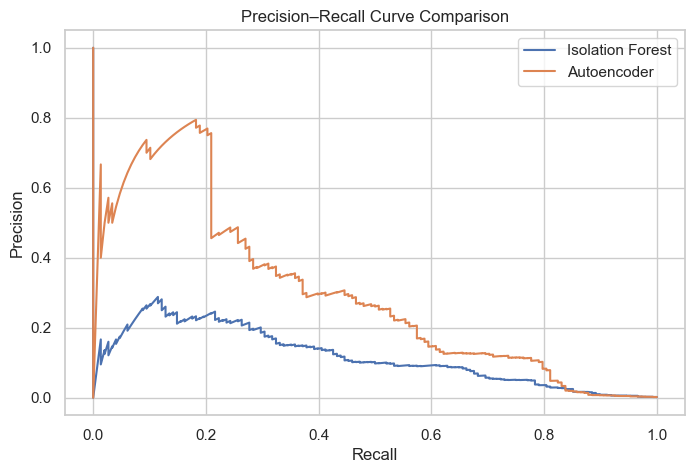

In [10]:
plt.plot(iso_rec, iso_prec, label="Isolation Forest")
plt.plot(ae_rec, ae_prec, label="Autoencoder")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison")
plt.legend()
plt.show()


# Confusion Matrices Side-by-Side (simple)

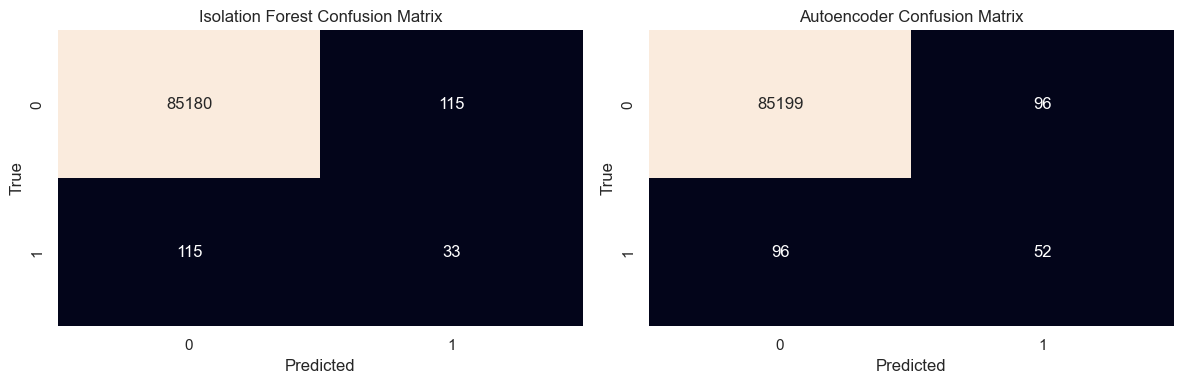

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.heatmap(iso_cm, annot=True, fmt="d", cbar=False, ax=axes[0])
axes[0].set_title("Isolation Forest Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(ae_cm, annot=True, fmt="d", cbar=False, ax=axes[1])
axes[1].set_title("Autoencoder Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()


Model Comparison Discussion

Both methods treat fraud as rare anomalies and aim to detect transactions that deviate from normal behaviour.

Isolation Forest isolates anomalies by random partitioning; it is fast, interpretable, and works well as a baseline.

The Autoencoder learns a compressed representation of normal transactions and flags high reconstruction error as anomalous.

Performance was evaluated using ROC-AUC and PR-AUC, with PR-AUC being more informative due to extreme class imbalance.

Thresholds were selected consistently by flagging the top ~fraud_rate fraction of transactions as anomalies, enabling a fair comparison.

In practice, the threshold would be chosen based on business trade-offs between catching more fraud (higher recall) and minimising false alarms (higher precision).